## Практическое задание №2
#### по дисциплине "Введение в анализ данных"

*Работу выполнил*: Евсеев Григорий, 3826Б1ПМад1

Работа выполнена с использованием IDE Visual Studio Code.

### Часть 1.

In [1]:
import xlrd
import statistics
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from collections import Counter

Загрузка данных в словарь:

In [2]:
book = xlrd.open_workbook('03_Стоимость_турпакетов.xlsx')
sheet = book.sheet_by_name('Отчет')

headers = [i for i in range(sheet.nrows)
           if str(sheet.cell_value(i,0)).strip().lower().startswith(('всего', 'гражданам'))]
expenses = {}
for k, start in enumerate(headers):
    end = headers[k+1] if (k+1) < len(headers) else sheet.nrows
    for i in range(start + 1, end):
        region = str(sheet.cell_value(i, 0)).strip().lower()
        if not region:
            continue
        expenses.setdefault(region, [[], [], [], []])
        try:
            expenses[region][k] = [float(sheet.cell_value(i, j)) for j in range(1, 8)]
        except ValueError:
            pass

In [3]:
expenses['белгородская область']

[[727960.5, 822657.0, 916406.0, 902520.0, 732558.9, 923334.0, 1147512.89],
 [41192.9, 24773.0, 73118.0, 209382.5, 175206.1, 112518.0, 123604.9],
 [686757.6, 797755.0, 843288.0, 693137.5, 557352.8, 810816.0, 1023908.0],
 [10.0, 129.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

In [4]:
expenses['белгородская область'][0][2016 - 2012]

732558.9

Формирование срезов данных и вспомогательных функций:

In [18]:
years      = np.arange(2012, 2019, step = 1)
categories = range(4)

def exp(category, year):
    res = []
    for name, region_data in expenses.items():
        if len(region_data[category]) < 7:
            continue
        if name == 'российская федерация':
            continue
        if 'федеральный округ' in name:
            continue
        res.append(region_data[category][year - 2012] / 1000000)
    return res

def CategToString(category):
    if category == 0:
        return "Всего"
    elif category == 1:
        return "Гр.РФ по тер.РФ"
    elif category == 2:
        return "Гр.РФ по др.странам"
    elif category == 3:
        return "Гр.др.стран по тер.РФ"

Поиск основных числовых характеристик центрального положения и разброса на примере суммарных данных в 2018 году:

In [19]:
print("Выборочное среднее = " + str(round(statistics.mean(exp(0, 2018)), 4)))
print("Усеченное среднее = " + str(round(stats.trim_mean(exp(0, 2018), 0.1), 4)))
print("Выборочная медиана = " + str(round(statistics.median(exp(0, 2018)), 4)))
print("Выборочная мода для группированных данных = " +
      str(statistics.mode(round(x) for x in exp(0, 2018))))
print("Мультимодальность для группированных данных: " +
      str(Counter(round(2 * x) / 2 for x in exp(0, 2018)).most_common(2)))
print("Выборочная дисперсия = " + str(round(statistics.variance(exp(0, 2018)), 4)))
print("Среднее квадратическое отклонение = " + str(round(statistics.stdev(exp(0, 2018)), 4)))

Выборочное среднее = 3.6112
Усеченное среднее = 1.8698
Выборочная медиана = 1.3891
Выборочная мода для группированных данных = 1
Мультимодальность для группированных данных: [(0.5, 14), (1.5, 14)]
Выборочная дисперсия = 134.341
Среднее квадратическое отклонение = 11.5906


Динамика характеристик по годам и категориям:

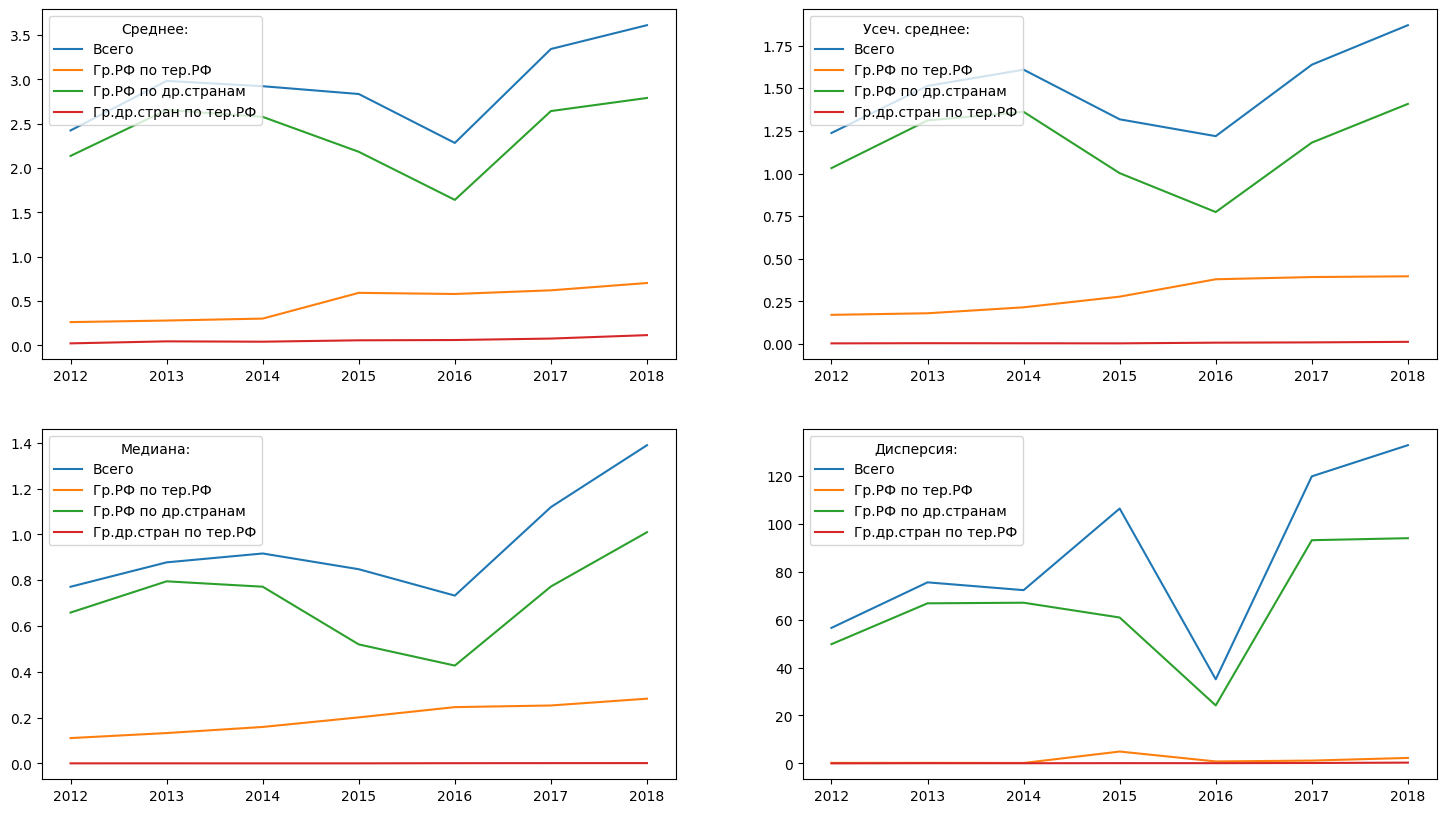

In [20]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (18, 10))

for category in categories:
    meanDynamics = []
    trimMeanDynamics = []
    medianDynamics = []
    varDynamics = []

    for year in years:
        meanDynamics.append(np.mean(exp(category, year)))
        trimMeanDynamics.append(stats.trim_mean(exp(category, year), 0.1))
        medianDynamics.append(np.median(exp(category, year)))
        varDynamics.append(np.var(exp(category, year)))

    axes[0][0].plot(years, meanDynamics, label = CategToString(category))
    axes[0][1].plot(years, trimMeanDynamics, label = CategToString(category))
    axes[1][0].plot(years, medianDynamics, label = CategToString(category))
    axes[1][1].plot(years, varDynamics, label = CategToString(category))

axes[0][0].legend(title = 'Среднее:', loc = 2)
axes[0][1].legend(title = 'Усеч. среднее:', loc = 2)
axes[1][0].legend(title = 'Медиана:', loc = 2)
axes[1][1].legend(title = 'Дисперсия:', loc = 2)

plt.show()

Квантили:

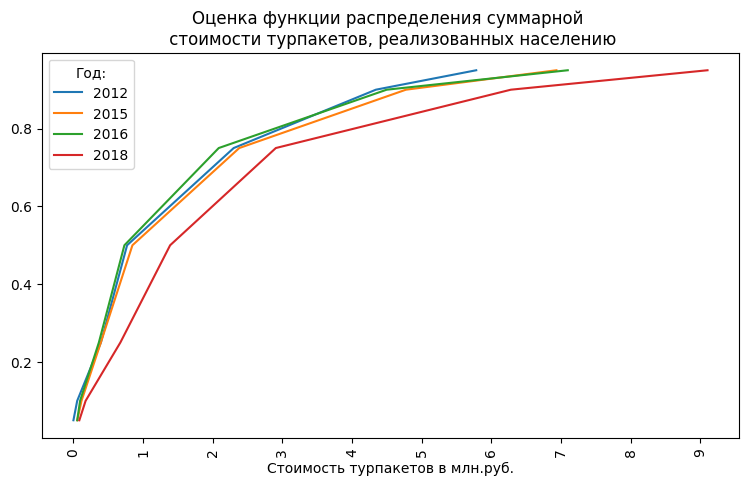

In [21]:
qlevels = [0.05, .1, .25, .5, .75, .9, .95]

def quantiles(category, year):
    res = []
    for q in qlevels:
        res.append(np.quantile(exp(category, year), q))
    return res

plt.figure(figsize = (9, 5))
plt.plot(quantiles(0, 2012), qlevels, label = '2012')
plt.plot(quantiles(0, 2015), qlevels, label = '2015')
plt.plot(quantiles(0, 2016), qlevels, label = '2016')
plt.plot(quantiles(0, 2018), qlevels, label = '2018')
plt.legend(title = 'Год:')
plt.xticks(np.arange(0, quantiles(0, 2018)[-1], step = 1.), rotation = 90)
plt.xlabel("Стоимость турпакетов в млн.руб.")
plt.title("Оценка функции распределения суммарной \n стоимости турпакетов, " +
          "реализованных населению")
plt.show()

Оценка по квантилям и эмпирической функции распределения (ЭФР):

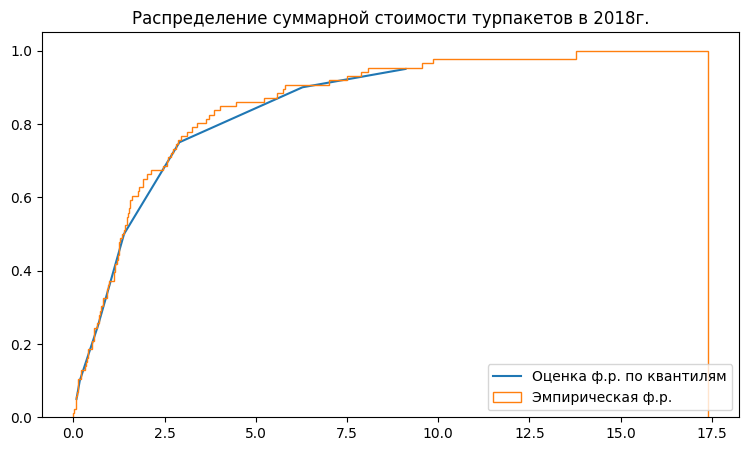

In [22]:
def trimTails(category, year):
    data = exp(category, year)
    data.sort()
    data = data[0:-1]
    return data

plt.figure(figsize = (9, 5))
plt.plot(quantiles(0, 2018), qlevels, label = "Оценка ф.р. по квантилям")
plt.hist(trimTails(0, 2018), bins = list(trimTails(0, 2018)),
         density = True, cumulative = True, histtype = 'step', fill = False,
         label = "Эмпирическая ф.р.")
plt.legend(loc = 4)
plt.title("Распределение суммарной стоимости турпакетов в 2018г.")
plt.show()

Коробчатая диаграмма:

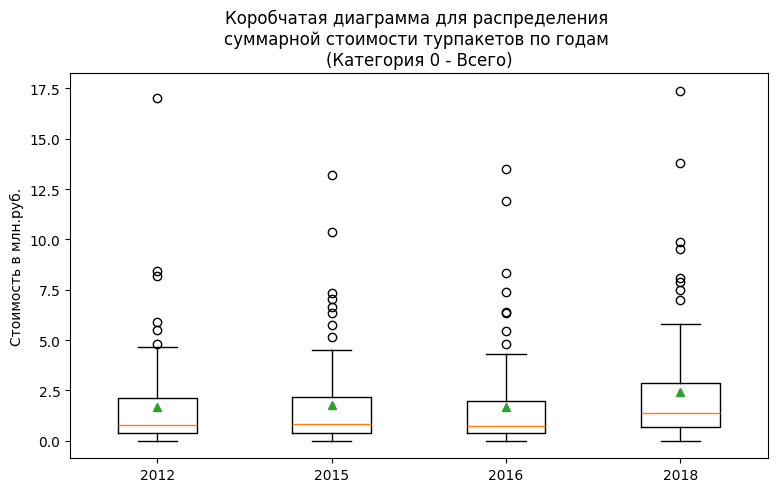

In [23]:
plt.figure(figsize = (9, 5))
plt.boxplot([trimTails(0, 2012), trimTails(0, 2015),
             trimTails(0, 2016), trimTails(0, 2018)],
            showmeans = True)
plt.xticks(np.arange(1, 5, step = 1), labels = [2012, 2015, 2016, 2018])
plt.title("Коробчатая диаграмма для распределения \n" +
          "суммарной стоимости турпакетов по годам \n(Категория 0 - Всего)")
plt.ylabel("Стоимость в млн.руб.")
plt.show()